In [1]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
plt.rcParams.update({
    'figure.figsize': (3.6, 2.7), 'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 'small', 'ytick.labelsize': 'small',
    'legend.fontsize': 'small', 'axes.titlesize': 'medium',
    'axes.spines.top': False, 'axes.spines.right': False,
    'image.interpolation': 'nearest', 'savefig.dpi': 100,
})

import os
import pickle
from pathlib import Path
import numpy as np
from jarvis.utils import tqdm

from hexarena import STORE_DIR
FIG_DIR = Path('figures')
os.makedirs(FIG_DIR, exist_ok=True)
rng = np.random.default_rng()

# Random policy in the foraging task

An environment using the Gamma (shape=10) schedule and the linear availability cue is initiated, and the behavior of a random policy is shown for one simulated episode.

In [2]:
from hexarena.env import ArenaForagingEnv

kappa = 0.1
taus = np.array([21, 14, 7])

env = ArenaForagingEnv(
    monkey={'move_price': 0.1},
    boxes=[{
        '_target_': 'hexarena.box.GammaBox', 'kappa': kappa, 'tau': tau,
    } for tau in taus],
)

In [3]:
n_steps = 10000

_, info = env.reset()
infos = [info]
actions = []
for _ in tqdm(range(n_steps), desc='Random policy', unit='step'):
    action = env.action_space.sample().item()
    *_, info = env.step(action)
    actions.append(action)
    infos.append(info)

Random policy:   0%|                                                                                          …

## Example of one episode

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

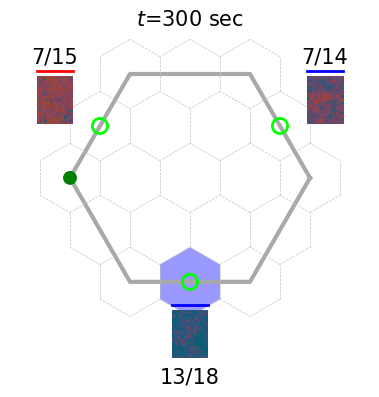

In [4]:
env_data = env.convert_simulated_data(infos, actions)

fig, ani = env.play_episode(**env_data, tmax=301)
# HTML(ani.to_jshtml())
ani.save(FIG_DIR/f'random.policy.mp4', dpi=200)

## Overview of push rates and spatial distributions

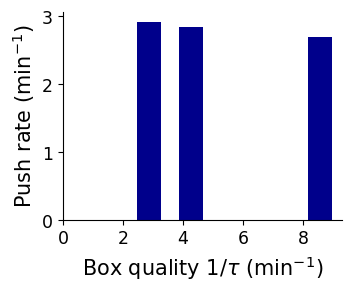

In [5]:
push_rates = np.array([(env_data['push']==i).sum()/n_steps*60 for i in range(env.n_boxes)]) # min^{-1}

_, ax = plt.subplots()
ax.bar(60/taus, push_rates, color='darkblue')
ax.set_xlim([0, None])
ax.set_xlabel(r'Box quality 1/$\tau$ (min$^{-1}$)')
ax.set_ylim([0, None])
ax.set_ylabel(r'Push rate (min$^{-1}$)')
plt.show()

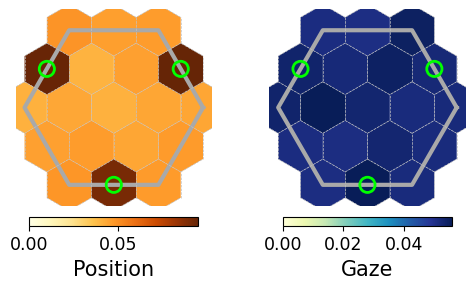

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for i, ax in enumerate(axes):
    if i==0:
        label = 'Position'
        vals = env_data['pos']
        cmap = 'YlOrBr'
    if i==1:
        label = 'Gaze'
        vals = env_data['gaze']
        cmap = 'YlGnBu'
    edges = np.arange(env.arena.n_tiles+1)-0.5
    counts, _ = np.histogram(vals, edges)
    probs = counts/counts.sum()
    env.arena.plot_map(
        ax, probs, vmin=0, vmax=probs.max(), cmap=cmap,
        cbar_kw={'label': label},
    )
plt.show()

# Train a policy with recurrent PPO algorithm

In [7]:
from gymnasium.wrappers import TimeLimit
from sb3_contrib import RecurrentPPO
from irc.utils import ProgressBarCallback

n_steps = 2000 # time steps per update in PPO
batch_size = 100 # batch size in PPO

algo = RecurrentPPO(
    policy='MultiInputLstmPolicy', env=TimeLimit(env, 1000),
    n_steps=n_steps, batch_size=batch_size,
    gamma=0.99, ent_coef=0.01,
)

logs = []
env.reset()
n_updates = 2000
algo.policy.set_training_mode(True)
with tqdm(total=n_updates, unit='update') as pbar:
    pbar_cb = ProgressBarCallback(pbar, disp_freq=n_steps)
    pbar_cb.logs = logs
    algo.env.envs[0].needs_reset = False
    algo.learn(
        total_timesteps=n_updates*n_steps,
        callback=pbar_cb, reset_num_timesteps=False,
    )
algo.policy.set_training_mode(False)

ModuleNotFoundError: No module named 'sb3_contrib'

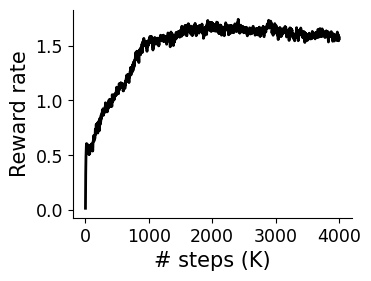

In [ ]:
_, ax = plt.subplots()
ax.plot(np.arange(1, n_updates+1)*n_steps/1000, logs, color='black')
ax.set_xlabel('# steps (K)')
ax.set_ylabel('Reward rate')
plt.show()

## Example of one episode

In [ ]:
n_steps = 5000

observation, info = env.reset()
infos = [info]
actions = []

state = None
for t in tqdm(range(n_steps), desc='Trained policy', unit='step'):
    action, state = algo.policy.predict(observation, state=state, episode_start=t==0)
    observation, *_, info = env.step(action)
    actions.append(action)
    infos.append(info)
actions = np.stack(actions)

Trained policy:   0%|                                                                                         …

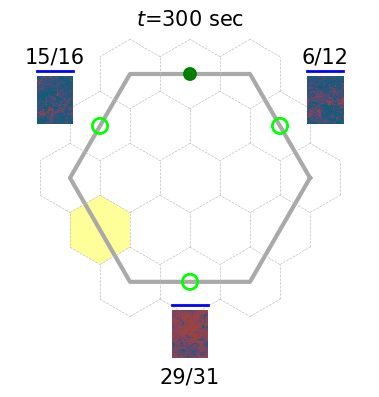

In [ ]:
env_data = env.convert_simulated_data(infos, actions)

fig, ani = env.play_episode(**env_data, tmax=301)
# HTML(ani.to_jshtml())
ani.save(FIG_DIR/f'PPO.policy.mp4', dpi=200)

## Overview of push rates and spatial distributions

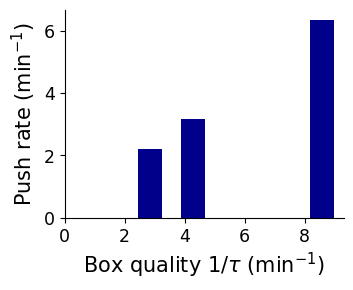

In [ ]:
push_rates = np.array([(env_data['push']==i).sum()/n_steps*60 for i in range(env.n_boxes)]) # min^{-1}

_, ax = plt.subplots()
ax.bar(60/taus, push_rates, color='darkblue')
ax.set_xlim([0, None])
ax.set_xlabel(r'Box quality 1/$\tau$ (min$^{-1}$)')
ax.set_ylim([0, None])
ax.set_ylabel(r'Push rate (min$^{-1}$)')
plt.show()

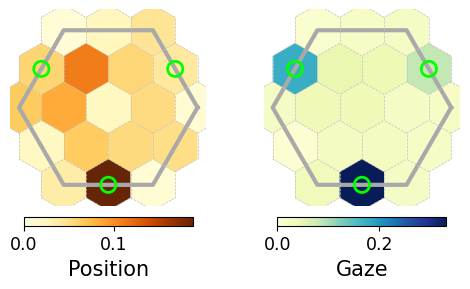

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for i, ax in enumerate(axes):
    if i==0:
        label = 'Position'
        vals = env_data['pos']
        cmap = 'YlOrBr'
    if i==1:
        label = 'Gaze'
        vals = env_data['gaze']
        cmap = 'YlGnBu'
    edges = np.arange(env.arena.n_tiles+1)-0.5
    counts, _ = np.histogram(vals, edges)
    probs = counts/counts.sum()
    env.arena.plot_map(
        ax, probs, vmin=0, vmax=probs.max(), cmap=cmap,
        cbar_kw={'label': label},
    )
plt.show()